### Prepared by: 
Yuting Chen 259430, 
Kacper Miklaszewski 243215, 
Jakub Szlarzyński 241004

# Step1_Data Collection

In [1]:
# libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")
sns.set_theme()
from scipy import stats   

## 1.1 Basic Inspection

In [2]:
# load dataset
CSV_NAME = "student_sleep_patterns.csv"
df = pd.read_csv(CSV_NAME)

# structure, columns, data types
print("=== Dataset Structure ===")
print("Shape (rows, columns):", df.shape)

print("\n=== Column Names ===")
print(list(df.columns))

print("\n=== First 5 Rows ===")
display(df.head())

print("\n=== Data Types and Non-Null Counts ===")
df.info()

=== Dataset Structure ===
Shape (rows, columns): (500, 14)

=== Column Names ===
['Student_ID', 'Age', 'Gender', 'University_Year', 'Sleep_Duration', 'Study_Hours', 'Screen_Time', 'Caffeine_Intake', 'Physical_Activity', 'Sleep_Quality', 'Weekday_Sleep_Start', 'Weekend_Sleep_Start', 'Weekday_Sleep_End', 'Weekend_Sleep_End']

=== First 5 Rows ===


,Student_ID,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,1,24,Other,2nd Year,7.7,7.9,3.4,2,37,10,14.16,4.05,7.41,7.06
1,2,21,Male,1st Year,6.3,6.0,1.9,5,74,2,8.73,7.10,8.21,10.21
2,3,22,Male,4th Year,5.1,6.7,3.9,5,53,5,20.00,20.47,6.88,10.92
3,4,24,Other,4th Year,6.3,8.6,2.8,4,55,9,19.82,4.08,6.69,9.42
4,5,20,Male,4th Year,4.7,2.7,2.7,0,85,3,20.98,6.12,8.98,9.01



=== Data Types and Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           500 non-null    int64  
 1   Age                  500 non-null    int64  
 2   Gender               500 non-null    object 
 3   University_Year      500 non-null    object 
 4   Sleep_Duration       500 non-null    float64
 5   Study_Hours          500 non-null    float64
 6   Screen_Time          500 non-null    float64
 7   Caffeine_Intake      500 non-null    int64  
 8   Physical_Activity    500 non-null    int64  
 9   Sleep_Quality        500 non-null    int64  
 10  Weekday_Sleep_Start  500 non-null    float64
 11  Weekend_Sleep_Start  500 non-null    float64
 12  Weekday_Sleep_End    500 non-null    float64
 13  Weekend_Sleep_End    500 non-null    float64
dtypes: float64(7), int64(5), object(2)
memory usage: 5

## 1.2 Metadata & Missing Check

In [3]:
print("\n=== Metadata Summary ===")

print("\n- Number of rows:", df.shape[0])
print("- Number of columns:", df.shape[1])

print("\n========= Data types =========")
print(df.dtypes)

print("\n=== Variable type summary ===")
print(df.dtypes.value_counts())

print("\n=== Missing Value Check ===")
total_missing = df.isna().sum().sum()

if total_missing == 0:
    print("No missing values in the dataset.")
else:
    print(df.isna().sum())
    print("\nMissing Value Percentage (%):")
    print((df.isna().mean() * 100).round(2))


=== Metadata Summary ===

- Number of rows: 500
- Number of columns: 14

========= Data types =========
Student_ID               int64
Age                      int64
Gender                  object
University_Year         object
Sleep_Duration         float64
Study_Hours            float64
Screen_Time            float64
Caffeine_Intake          int64
Physical_Activity        int64
Sleep_Quality            int64
Weekday_Sleep_Start    float64
Weekend_Sleep_Start    float64
Weekday_Sleep_End      float64
Weekend_Sleep_End      float64
dtype: object

=== Variable type summary ===
float64    7
int64      5
object     2
Name: count, dtype: int64

=== Missing Value Check ===
No missing values in the dataset.


# Step2_Data Cleaning

## 2.1 Remove Duplicate Rows

In [4]:
# Load raw dataset
df = pd.read_csv("student_sleep_patterns.csv")

#2.1a Identify column types
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=== Numeric Columns ===")
for col in num_cols:
    print("-", col)    
print(f"Total numeric columns: {len(num_cols)}")

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n=== Categorical Columns ===")
for col in cat_cols:
    print("-", col)
print(f"Total categorical columns: {len(cat_cols)}")

#2.1b Remove duplicates
print("\n=== 2.1b Remove Duplicate Rows ===")

before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"Removed {before - after} duplicate rows.")
print(f"New shape: {df.shape}")

=== Numeric Columns ===
- Student_ID
- Age
- Sleep_Duration
- Study_Hours
- Screen_Time
- Caffeine_Intake
- Physical_Activity
- Sleep_Quality
- Weekday_Sleep_Start
- Weekend_Sleep_Start
- Weekday_Sleep_End
- Weekend_Sleep_End
Total numeric columns: 12

=== Categorical Columns ===
- Gender
- University_Year
Total categorical columns: 2

=== 2.1b Remove Duplicate Rows ===
Removed 0 duplicate rows.
New shape: (500, 14)


## 2.2 Numeric Data Cleaning 

In [5]:
#2.2a Fix numeric data types
print("============ 2.2a: Fix numeric data types ============")

converted_cols = []

for col in num_cols:
    # Only convert if column is NOT already numeric
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors='coerce')
        converted_cols.append(col)

if converted_cols:
    print("Converted to numeric:", converted_cols)
else:
    print("All numeric columns are already correct numeric types.")

print("\n=== Numeric Column Types After Conversion ===")
print(df[num_cols].dtypes)

============ 2.2a: Fix numeric data types ============
All numeric columns are already correct numeric types.

=== Numeric Column Types After Conversion ===
Student_ID               int64
Age                      int64
Sleep_Duration         float64
Study_Hours            float64
Screen_Time            float64
Caffeine_Intake          int64
Physical_Activity        int64
Sleep_Quality            int64
Weekday_Sleep_Start    float64
Weekend_Sleep_Start    float64
Weekday_Sleep_End      float64
Weekend_Sleep_End      float64
dtype: object


In [6]:
#2.2c Detect & handle outliers
print("=== 2.2c: Detect & handle outliers (IQR) ===")

EXCLUDE_FROM_OUTLIERS = ["Student_ID"]
num_for_outliers = [c for c in num_cols if c not in EXCLUDE_FROM_OUTLIERS]
OUTLIER_STRATEGY = "cap"

iqr_summary = {}

for col in num_for_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    count = int(mask.sum())

    if count > 0:  # only show if outliers exist
        iqr_summary[col] = {
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2),
            "Outlier_Count": count
        }

        # cap strategy
        if OUTLIER_STRATEGY == "cap":
            df[col] = df[col].clip(lower=lower, upper=upper)
            print(f"✔ {col}: {count} outliers capped")

# Final summary
if not iqr_summary:
    print("No numeric outliers detected")
else:
    print("\n=== Outlier Summary ===")
    for col, info in iqr_summary.items():
        print(f"{col}: {info}")

=== 2.2c: Detect & handle outliers (IQR) ===
No numeric outliers detected


## 2.3 Categorical/Text Data Cleaning 

In [7]:
#2.3b Standardize & clean labels
print("============== 2.3c: Standardize & clean categorical/text labels ==============")

for col in cat_cols:
    # Work in string space for safe text operations
    s = df[col].astype("string")

    # Basic normalization: strip, lowercase, collapse multiple spaces
    s = s.str.strip()                      # remove leading/trailing spaces
    s = s.str.lower()                      # normalize case
    s = s.str.replace(r"\s+", " ", regex=True)  # collapse multiple spaces into one

    # Convert back to categorical type
    df[col] = s.astype("category")

    print(f"Cleaned and standardized labels in '{col}' and converted to category.")

============== 2.3c: Standardize & clean categorical/text labels ==============
Cleaned and standardized labels in 'Gender' and converted to category.
Cleaned and standardized labels in 'University_Year' and converted to category.


In [8]:
#2.3c Verify unique values
print("\n================= Unique values after cleaning ==================")
for col in cat_cols:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")


================= Unique values after cleaning ==================
Gender: ['female', 'male', 'other']
University_Year: ['1st year', '2nd year', '3rd year', '4th year']


## 2.4 Datetime/Time Data Cleaning 

In [9]:
#2.4a Fix datetime types
print("=== 2.4a: Safe datetime detection & conversion ===")

datetime_cols = []

# Only columns explicitly containing the word "date"
candidate_cols = [col for col in df.columns if "date" in col.lower()]

for col in candidate_cols:
    parsed = pd.to_datetime(df[col], errors="coerce")
    if parsed.notna().sum() > 0:
        df[col] = parsed
        datetime_cols.append(col)
        print(f"{col} converted to datetime")

if not datetime_cols:
    print("No valid datetime columns detected.")
else:
    print("Detected datetime columns:", datetime_cols)

=== 2.4a: Safe datetime detection & conversion ===
No valid datetime columns detected.


## 2.5 Save Cleaned Dataset

In [10]:
print("=== 2.5: Save Cleaned Dataset ===")

# Create output folder if not exist
os.makedirs("data_clean", exist_ok=True)

# Define path and save
CLEAN_PATH = "data_clean/S2_cleaned_data.csv"
df.to_csv(CLEAN_PATH, index=False)

print(f"Cleaned dataset saved to: {CLEAN_PATH}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

=== 2.5: Save Cleaned Dataset ===
Cleaned dataset saved to: data_clean/S2_cleaned_data.csv
Shape: 500 rows × 14 columns


# Step3_EDA

## 3.1 Numerical Analysis

In [11]:
# load cleaned dataset
df = pd.read_csv("data_clean/S2_cleaned_data.csv")

#3.1a identify numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("===== Numeric Columns =====")
for col in num_cols:
    print("-", col)
    
print(f"Total numeric columns: {len(num_cols)}")

===== Numeric Columns =====
- Student_ID
- Age
- Sleep_Duration
- Study_Hours
- Screen_Time
- Caffeine_Intake
- Physical_Activity
- Sleep_Quality
- Weekday_Sleep_Start
- Weekend_Sleep_Start
- Weekday_Sleep_End
- Weekend_Sleep_End
Total numeric columns: 12


In [12]:
#3.1b descriptive statistics
desc_stats = df[num_cols].describe().T

print("========================== Descriptive Statistics(numeric) ==========================")
display(desc_stats.round(3))

========================== Descriptive Statistics(numeric) ==========================


,count,mean,std,min,25%,50%,75%,max
Student_ID,500.0,250.500,144.482,1.00,125.750,250.500,375.250,500.00
Age,500.0,21.536,2.333,18.00,20.000,21.000,24.000,25.00
Sleep_Duration,500.0,6.472,1.486,4.00,5.100,6.500,7.800,9.00
Study_Hours,500.0,5.982,3.476,0.10,2.900,6.050,8.800,12.00
Screen_Time,500.0,2.525,0.859,1.00,1.800,2.600,3.300,4.00
Caffeine_Intake,500.0,2.462,1.682,0.00,1.000,2.000,4.000,5.00
Physical_Activity,500.0,62.342,35.192,0.00,32.750,62.500,93.250,120.00
Sleep_Quality,500.0,5.362,2.967,1.00,3.000,5.000,8.000,10.00
Weekday_Sleep_Start,500.0,11.167,5.972,1.08,6.088,10.635,16.152,21.93
Weekend_Sleep_Start,500.0,12.376,5.790,2.05,7.298,12.690,17.328,22.00


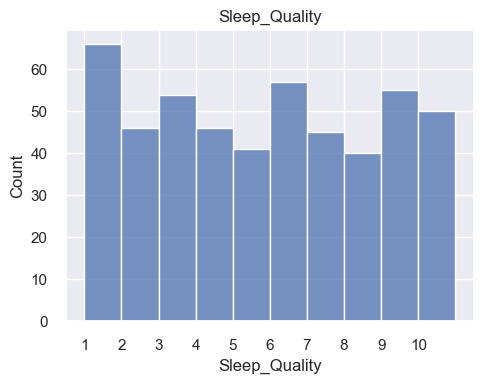

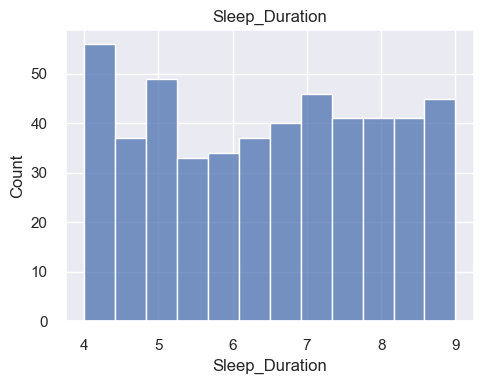

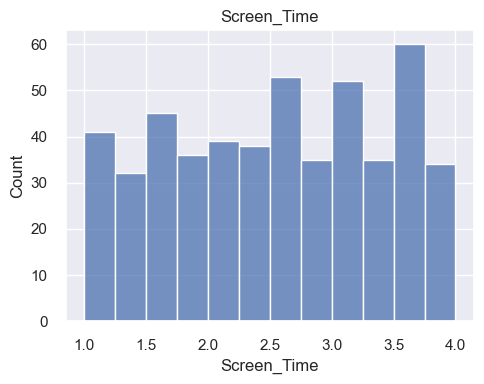

In [13]:
# 3.1c numeric distribution visualization
selected_num_cols = [
    'Sleep_Quality',
    'Sleep_Duration',
    'Screen_Time'
]

for col in selected_num_cols:
    plt.figure(figsize=(5,4))

    if col == 'Sleep_Quality':
        # Perfect bins for 1–10
        sns.histplot(df[col], bins=range(1,12), kde=False)
        plt.xticks(range(1,11))
    else:
        # Default for continuous variables
        sns.histplot(df[col], bins=12, kde=False)

    plt.title(col)
    plt.tight_layout()
    plt.show()

In [14]:
#3.1d normality check (Shapiro–Wilk)
from scipy.stats import shapiro
print("========== Normality Check (Shapiro–Wilk) ==========\n")

# select numeric variables to test
normality_cols = [
    'Sleep_Quality',
    'Sleep_Duration',
    'Screen_Time'
]

for col in normality_cols:
    print(f"--- Shapiro–Wilk Test for {col} ---")
    
    # drop missing if any
    data = df[col].dropna()
    
    # run test
    stat, p = shapiro(data)
    
    print(f"Statistic: {stat:.4f}")
    print(f"P-value : {p:.6f}")
    
    # interpretation
    if p > 0.05:
        print("Conclusion: Fail to reject H0 → Data looks normally distributed.\n")
    else:
        print("Conclusion: Reject H0 → Data is NOT normally distributed.\n")


========== Normality Check (Shapiro–Wilk) ==========

--- Shapiro–Wilk Test for Sleep_Quality ---
Statistic: 0.9263
P-value : 0.000000
Conclusion: Reject H0 → Data is NOT normally distributed.

--- Shapiro–Wilk Test for Sleep_Duration ---
Statistic: 0.9448
P-value : 0.000000
Conclusion: Reject H0 → Data is NOT normally distributed.

--- Shapiro–Wilk Test for Screen_Time ---
Statistic: 0.9545
P-value : 0.000000
Conclusion: Reject H0 → Data is NOT normally distributed.



### 3.1 Numerical Analysis Insight
1. Variation Across Habits
Study_Hours, Caffeine_Intake, Physical_Activity, and sleep timing all show large differences between students. This indicates that students follow very different daily routines, which may introduce noise and make patterns harder to model.

2. Distribution Patterns
Sleep_Quality spans the full 1–10 scale, showing both poor and good sleepers. Sleep_Duration mostly stays between 5–8 hours, while Screen_Time clusters around 2–3 hours. These patterns suggest typical student behavior but also some skewness.

3. Normality Results
Shapiro–Wilk tests show that Sleep_Quality, Sleep_Duration, and Screen_Time are not normally distributed (all p < 0.001). This means statistical methods that assume normality may not be suitable, and non-parametric tests or transformations may work better.

4. Risks and Modeling Implications
Wide ranges and non-normal distributions may affect stability of models and group comparisons. Feature scaling might be needed later, and relationships could be weaker or more nonlinear than expected.

## 3.2 Categorical Analysis

In [15]:
#3.2a identify Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("===== Categorical Columns =====")
for col in cat_cols:
    print("-", col)

print(f"Total categorical columns: {len(cat_cols)}")

===== Categorical Columns =====
- Gender
- University_Year
Total categorical columns: 2


In [16]:
#3.2b value distribution
print("=== Value Distribution (count + percent) ===")

for col in cat_cols:
    print(f"\n======== {col} ========")
    
    counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(dropna=False, normalize=True) * 100
    
    summary = pd.DataFrame({
        "count": counts,
        "percent": percents.round(2)
    })
    
    display(summary)

=== Value Distribution (count + percent) ===

======== Gender ========


,count,percent
Gender,,
male,186,37.2
female,166,33.2
other,148,29.6



======== University_Year ========


,count,percent
University_Year,,
3rd year,132,26.4
2nd year,131,26.2
1st year,125,25.0
4th year,112,22.4


============= Categorical Distribution Visualization =============


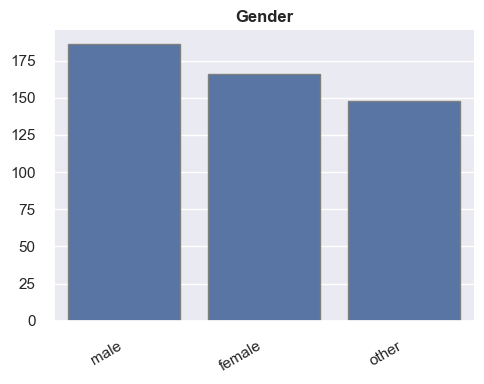

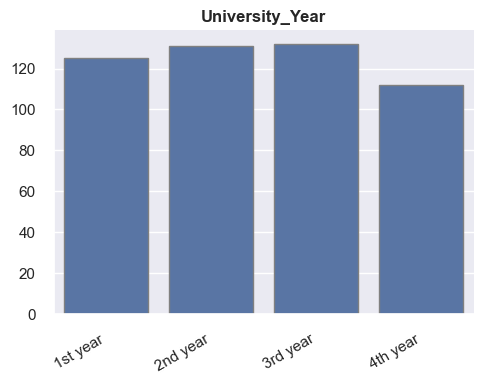

In [17]:
#3.2c Categorical distribution viaualization
print("============= Categorical Distribution Visualization =============")

year_order = ["1st year", "2nd year", "3rd year", "4th year"]
gender_order = ["male", "female", "other"]

for cat_col in cat_cols:
    plt.figure(figsize=(5,4))

    if cat_col == "University_Year":
        order = year_order
    elif cat_col == "Gender":
        order = gender_order
    else:
        order = None

    sns.countplot(
        data=df,
        x=cat_col,
        order=order,
        edgecolor="gray"
    )

    plt.title(cat_col, fontsize=12, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=30, ha="right")

    sns.despine()
    plt.tight_layout()
    plt.show()

### 3.2 Categorical Analysis Insight
1. Overall pattern
Gender is divided into three groups of similar size. University_Year also shows an even spread across the four levels.

2. Meaning
Because both variables are balanced, group comparisons are more reliable and not dominated by one specific category.

3. Data quality
There are no missing values, and category labels are clean and consistent.

## 3.3 Correlation and Relationships


================================== Correlation Heatmap (All Numeric Columns) ==================================


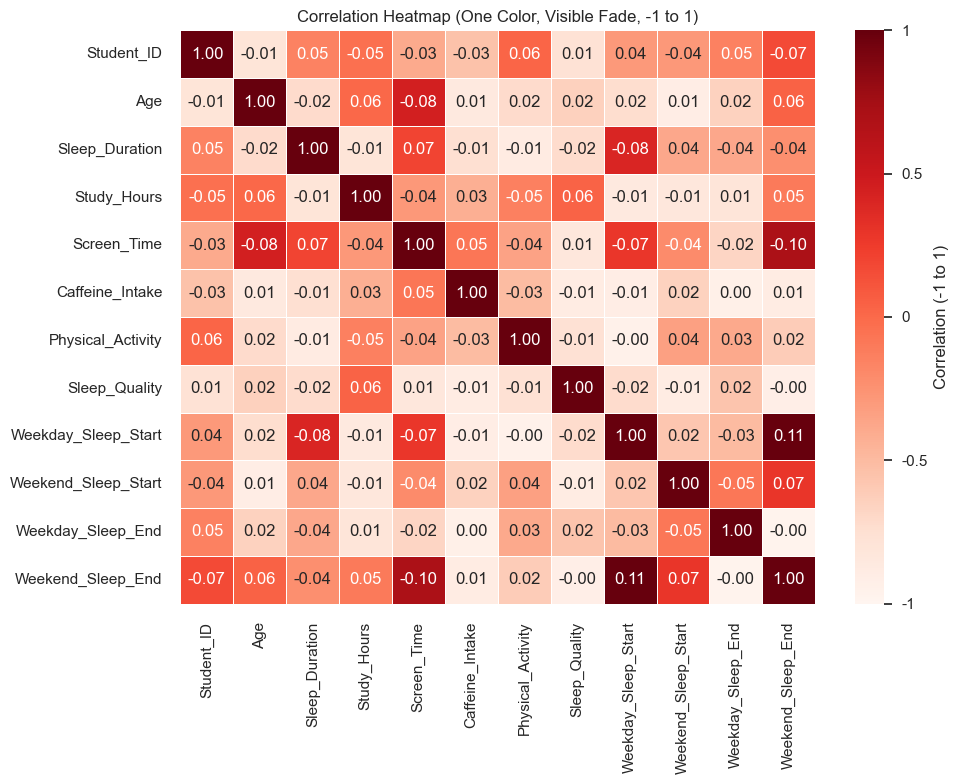


========================= Pairplot (Selected Numeric Features) =========================


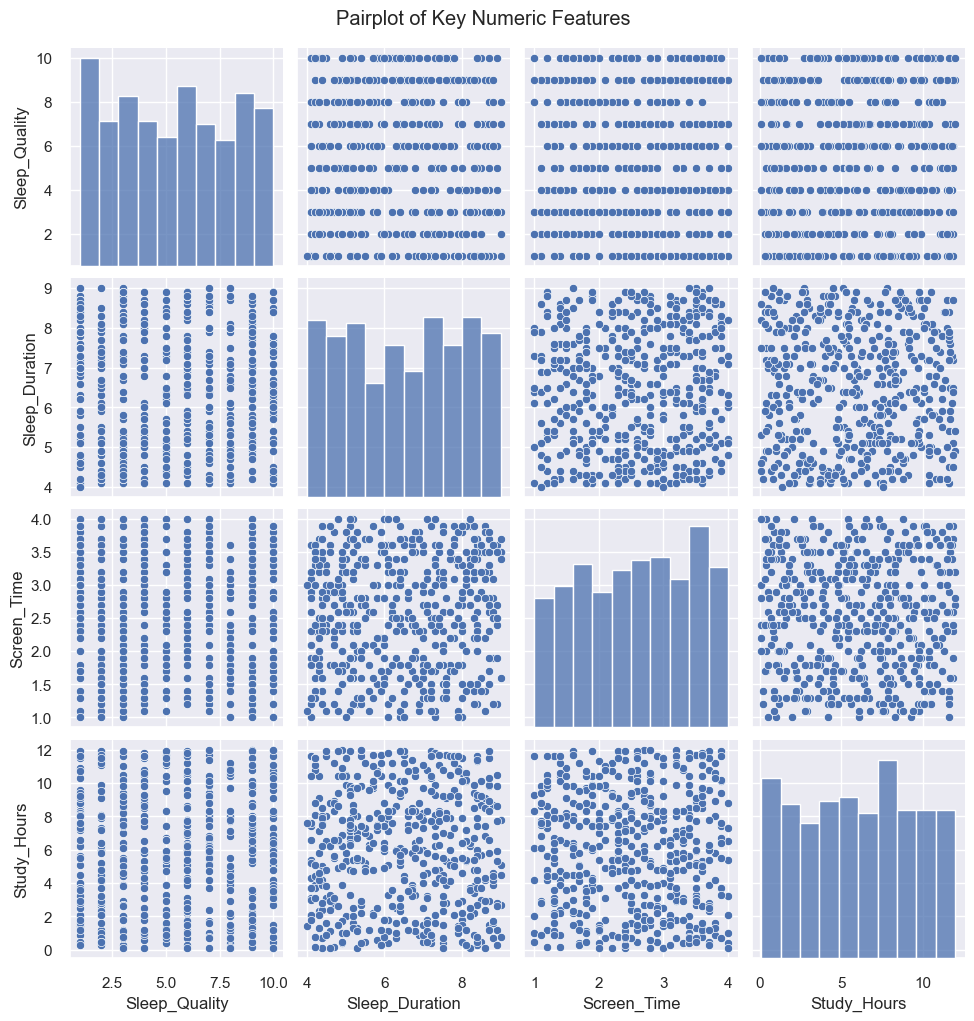


============== Scatter Plots (Selected Numeric Pairs) ================


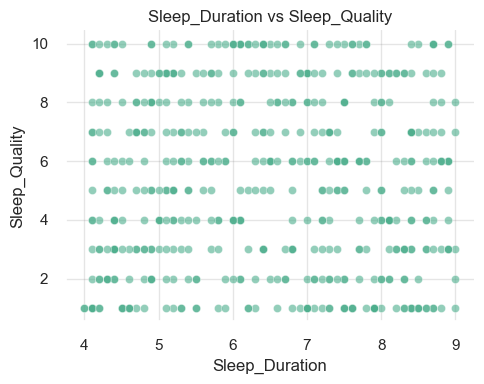

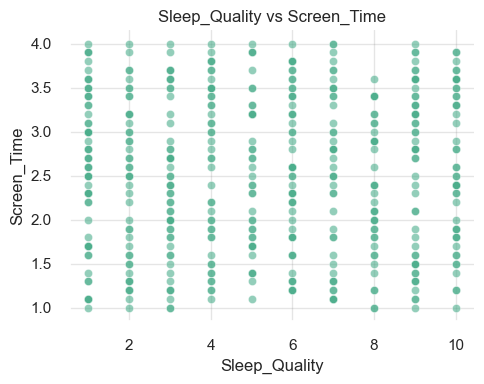

In [18]:
#3.3a numeric-numeric
# Correlation heatmap (all numeric columns)
print("\n================================== Correlation Heatmap (All Numeric Columns) ==================================")
import numpy as np
plt.figure(figsize=(10, 8))

corr = df[num_cols].corr()        # real correlation (-1..1)
abs_corr = corr.abs()             # magnitude

# mask to drop the diagonal (1.00)
mask = ~np.eye(abs_corr.shape[0], dtype=bool)
max_offdiag = abs_corr.values[mask].max()      # e.g. ~0.11

# scaled 0..1 for all off-diagonal cells
scaled = (abs_corr / max_offdiag).clip(0, 1)

ax = sns.heatmap(
    scaled,                       # color = scaled magnitude 0..1
    annot=corr,                   # show real -1..1 values
    fmt=".2f",
    cmap="Reds",                 # ONE color
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor="white"
)

# colorbar ticks shown as -1..1
cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels([-1, -0.5, 0, 0.5, 1])
cbar.set_label("Correlation (-1 to 1)")

plt.title("Correlation Heatmap (One Color, Visible Fade, -1 to 1)")
plt.tight_layout()
plt.show()

# 3.3a numeric-numeric (continued) – Pairplot for selected variables
print("\n========================= Pairplot (Selected Numeric Features) =========================")

pairplot_cols = [
    "Sleep_Quality",
    "Sleep_Duration",
    "Screen_Time",
    "Study_Hours"
]

sns.pairplot(
    df[pairplot_cols],
    diag_kind="hist"
)
plt.suptitle("Pairplot of Key Numeric Features", y=1.02)
plt.show()


# Define the selected pairs
pairs = [
    ("Sleep_Duration", "Sleep_Quality"),
    ("Sleep_Quality", "Screen_Time"),
]

# Scatter plots for selected pairs (with regression line)
print("\n============== Scatter Plots (Selected Numeric Pairs) ================")

for x, y in pairs:
    plt.figure(figsize=(5,4))
    ax = plt.gca()
    ax.set_facecolor("white")
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        color="#4cae8c",       # soft green
        alpha=0.6,             # transparency
        s=35                   # point size
    )

    plt.title(f"{x} vs {y}", fontsize=12)
    plt.grid(True, color='gray', alpha=0.2)  # light grid background
    sns.despine()  # cleaner edges
    plt.tight_layout()
    plt.show()
    


=========== Boxplots (Selected Numeric–Categorical Pairs) =============


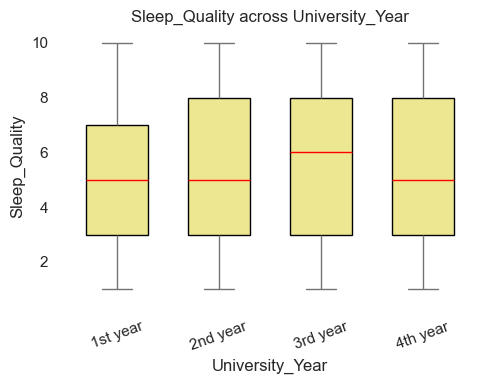

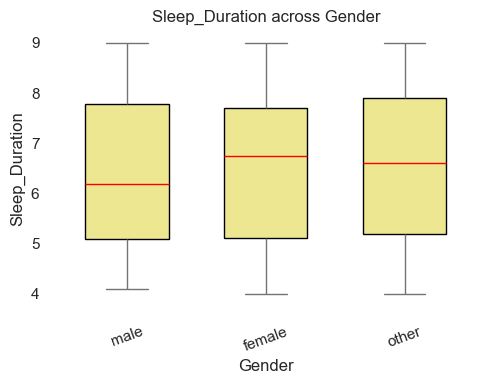

In [19]:
#3.3b numeric-categorical
# Define your selected numeric–categorical pairs
pairs_3_3b = [
    ("Sleep_Quality", "University_Year"),
    ("Sleep_Duration", "Gender")
]

year_order = ["1st year", "2nd year", "3rd year", "4th year"]
gender_order = ["male","female", "other"]   

# Boxplots for each pair
print("\n=========== Boxplots (Selected Numeric–Categorical Pairs) =============")
for num, cat_col in pairs_3_3b:
    plt.figure(figsize=(5,4), facecolor="white")   # white background for the whole figure
    
    ax = plt.gca()
    ax.set_facecolor("white")                      # white plot area

    if cat_col == "University_Year":
        order = year_order
    elif cat_col == "Gender":
        order = gender_order
    else:
        order = None
    
    sns.boxplot(
        data=df,
        x=cat_col,
        y=num,
        order = order,
        color="#fcf483",      
        width=0.6,            
        boxprops=dict(edgecolor='black'),
        medianprops=dict(color='red')
    )

    plt.title(f"{num} across {cat_col}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

========== Crosstab: Gender vs University_Year ==========
University_Year  1st year  2nd year  3rd year  4th year
Gender                                                 
female                 43        38        45        40
male                   44        54        48        40
other                  38        39        39        32


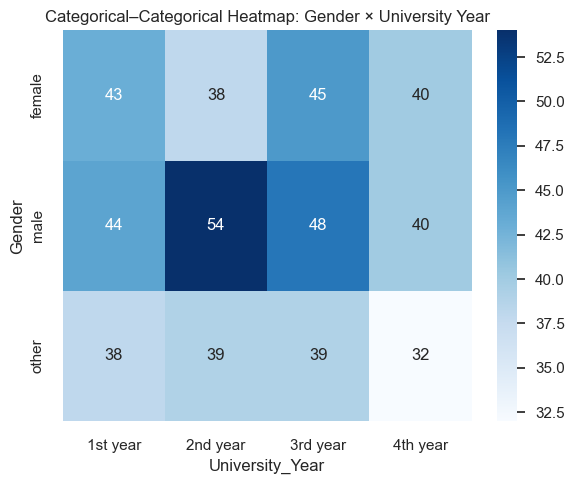

========== Chi-Squared Test: Gender × University_Year ==========

Chi-square statistic: 1.8562
Degrees of freedom: 6
P-value: 0.9324378323184905

Conclusion: Fail to reject H0 → Gender and University_Year appear independent.



In [20]:
#3.3c categorical-categorical
# Crosstab between the two categorical variables
print("========== Crosstab: Gender vs University_Year ==========")
crosstab = pd.crosstab(df["Gender"], df["University_Year"])
print(crosstab)

# Heatmap of the crosstab
plt.figure(figsize=(6,5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("Categorical–Categorical Heatmap: Gender × University Year")
plt.tight_layout()
plt.show()

from scipy.stats import chi2_contingency

print("========== Chi-Squared Test: Gender × University_Year ==========\n")
chi2, p, dof, expected = chi2_contingency(crosstab)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print("P-value:", p)

if p > 0.05:
    print("\nConclusion: Fail to reject H0 → Gender and University_Year appear independent.\n")
else:
    print("\nConclusion: Reject H0 → Gender and University_Year are NOT independent.\n")

In [21]:
#3.3d collinearity inspection
print("\n=== Collinearity Inspection (|r| > 0.8) ===")

# Correlation matrix for numeric features
corr_matrix = df[num_cols].corr().abs()

# Find highly correlated pairs
high_corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Filter pairs with strong collinearity (|r| > 0.8)
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.8]

print(high_corr_pairs)


=== Collinearity Inspection (|r| > 0.8) ===
Empty DataFrame
Columns: [Feature_1, Feature_2, Correlation]
Index: []


### 3.3 Correlation and Relationships Insight
1. Overall correlation
The heatmap shows correlations close to zero across all numeric variables, indicating no strong linear relationships.
2. Pairplot patterns
The pairplot of key numeric features (Sleep_Quality, Sleep_Duration, Screen_Time, Study_Hours) also shows scattered and unstructured patterns, supporting the idea that simple linear relationships are weak.
3. Sleep-related relationships
The scatter plots show no clear trend between Sleep_Quality and Sleep_Duration or Screen_Time, suggesting sleep quality may depend on multiple small or non-linear factors.
4. Categorical dependency
The chi-square test (p = 0.93) confirms that Gender and University_Year are independent, with no meaningful association.
5. Group differences
Boxplots show almost identical distributions across groups. This matches the ANOVA and t-test results, which show no significant differences.
6. Collinearity
No feature pair exceeds |r| > 0.8, so there are no collinearity issues and all numeric features can be used safely in modeling.

## 3.4 Group Comparisons

In [22]:
#3.4a define grouping variables
groupings_3_4 = [
    ("Gender", "Sleep_Quality"),
    ("Gender", "Sleep_Duration"),
    ("University_Year", "Sleep_Quality"),
    ("University_Year", "Sleep_Duration")
]

print("\n- Selected Groupings (cat_col, num_col):")
for group in groupings_3_4:
    print(group)


- Selected Groupings (cat_col, num_col):
('Gender', 'Sleep_Quality')
('Gender', 'Sleep_Duration')
('University_Year', 'Sleep_Quality')
('University_Year', 'Sleep_Duration')


In [23]:
#3.4b compare group  statistics
print("============== Group Statistics ==============")

for cat_col, num_col in groupings_3_4:
    print(f"\n-------- {num_col} by {cat_col} ---------")
    
    stats_table = df.groupby(cat_col, observed=True)[num_col].agg(
    ['count', 'mean', 'median', 'std']
)
    
    print(stats_table)

============== Group Statistics ==============

-------- Sleep_Quality by Gender ---------
        count      mean  median       std
Gender                                   
female    166  5.554217     6.0  2.842334
male      186  5.102151     5.0  3.025173
other     148  5.472973     5.5  3.026967

-------- Sleep_Duration by Gender ---------
        count      mean  median       std
Gender                                   
female    166  6.531928    6.75  1.501153
male      186  6.358065    6.20  1.485921
other     148  6.549324    6.60  1.469300

-------- Sleep_Quality by University_Year ---------
                 count      mean  median       std
University_Year                                   
1st year           125  5.240000     5.0  2.803799
2nd year           131  5.320611     5.0  2.998120
3rd year           132  5.545455     6.0  3.136497
4th year           112  5.330357     5.0  2.932847

-------- Sleep_Duration by University_Year ---------
                 count      mea

==================== Group Visual Comparisons =====================


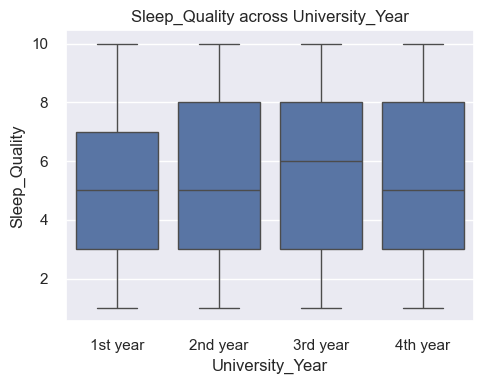

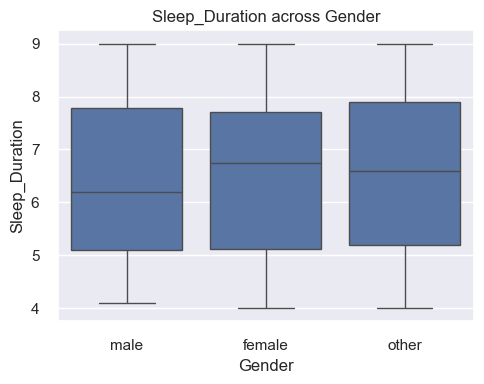

In [24]:
#3.4c visual comparsion
print("==================== Group Visual Comparisons =====================")

year_order = ["1st year", "2nd year", "3rd year", "4th year"]
gender_order = ["male", "female", "other"]

groupings_3_4 = [
    ("University_Year", "Sleep_Quality"),
    ("Gender", "Sleep_Duration")
]

for cat_col, num_col in groupings_3_4:

    # Choose correct order
    if cat_col == "University_Year":
        order = year_order
    elif cat_col == "Gender":
        order = gender_order
    else:
        order = None

    # Plot
    plt.figure(figsize=(5,4))
    sns.boxplot(data=df, x=cat_col, y=num_col, order=order)
    plt.title(f"{num_col} across {cat_col}")
    plt.tight_layout()
    plt.show()

In [25]:
#3.4d statistic comparsion
from scipy.stats import f_oneway

print("=========== Statistical Comparison (ANOVA) ==========")

groupings_3_4 = [
    ("University_Year", "Sleep_Quality"),
    ("Gender", "Sleep_Duration")
]

for cat_col, num_col in groupings_3_4:
    print(f"\n--------------------- {num_col} across {cat_col} ----------------------")
    
    # Collect values per group
    group_names = []
    group_values = []
    
    for name, group in df.groupby(cat_col, observed=True):
        group_names.append(name)
        vals = group[num_col].dropna().values
        group_values.append(vals)
    
    # Optional: show group sizes
    sizes = {name: len(vals) for name, vals in zip(group_names, group_values)}
    print("Group sizes:", sizes)
    
    # Run one-way ANOVA
    F, p = f_oneway(*group_values)
    
    print(f"F-statistic: {F:.4f}")
    print(f"p-value: {p:.6f}")
    
    from scipy.stats import ttest_ind

print("\n============= Statistical Comparison (T-test) ============\n")

# Example: Sleep_Duration difference between Male and Female
male_vals = df[df["Gender"] == "male"]["Sleep_Duration"].dropna()
female_vals = df[df["Gender"] == "female"]["Sleep_Duration"].dropna()

# Run independent t-test
t_stat, p_val = ttest_ind(male_vals, female_vals, equal_var=False)

print("T-test: Sleep_Duration between Male and Female")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")

if p_val > 0.05:
    print("Conclusion: Fail to reject H0 → No significant difference.\n")
else:
    print("Conclusion: Reject H0 → Significant difference detected.\n")

=========== Statistical Comparison (ANOVA) ==========

--------------------- Sleep_Quality across University_Year ----------------------
Group sizes: {'1st year': 125, '2nd year': 131, '3rd year': 132, '4th year': 112}
F-statistic: 0.2502
p-value: 0.861172

--------------------- Sleep_Duration across Gender ----------------------
Group sizes: {'female': 166, 'male': 186, 'other': 148}
F-statistic: 0.8819
p-value: 0.414635

============= Statistical Comparison (T-test) ============

T-test: Sleep_Duration between Male and Female
T-statistic: -1.0899
P-value: 0.276504
Conclusion: Fail to reject H0 → No significant difference.



### 3.4 Group Comparisons Insight
1. Visual patterns
The boxplots show very similar shapes across groups. Sleep_Quality looks the same for all university years, and Sleep_Duration overlaps strongly across male, female, and other.
2. Group statistics
Mean and median values differ only slightly. Sleep_Duration stays around 6.3–6.6 hours, and Sleep_Quality stays around 5–6 across all categories.
3. ANOVA results
Both ANOVAs give high p-values (> 0.4 and > 0.86), confirming no significant differences between university years or gender groups.
4. T-test results
The t-test for Sleep_Duration between male and female (p = 0.28) also shows no meaningful difference, supporting the ANOVA findings.

## 3.5 EDA Insights Summary & Modeling Implications
1. Feature Statistics & Risks
The dataset is clean and balanced, with no missing values or inconsistent labels. Numeric features show realistic ranges of student behaviors—study hours, screen time, caffeine intake, and physical activity.
However, the wide variation in these habits may introduce noise, and differences in scale suggest that future models may require normalization or standardization.

2. Distribution Insights
Sleep_Quality spans across almost the full 1–10 scale, showing both poor and good sleepers.
Sleep_Duration mainly falls between 5–8 hours, which is typical for university students.
Other lifestyle variables show high diversity, meaning students follow very different routines.
These patterns indicate that sleep outcomes may rely on multiple small factors rather than one strong feature.

3. Relationships and Statistical Tests
Correlations between numeric variables are all weak (close to zero). The pairplot also shows scattered distributions with no clear patterns between key sleep-related variables.
Categorical analyses show minimal group differences, supported by statistical tests:
--ANOVA shows no significant differences in Sleep_Quality across university years.
--T-test shows no significant Sleep_Duration difference between male and female students.
--Chi-Squared test confirms Gender and University_Year are independent.
These results suggest that relationships in the dataset are weak, and simple linear associations may not capture underlying patterns.

4. Data Quality & Collinearity
No feature pair exceeds |r| > 0.8, indicating no multicollinearity issues.
All features can be used safely in early modeling without redundant predictors.

5. Modeling Implications
Because relationships are weak:
No single feature is a strong predictor → models must rely on combining multiple signals.
Feature engineering becomes important → new features (e.g., bedtime shift, weekend vs weekday differences, study/screen ratios) may reveal deeper patterns.
Flexible or non-linear models such as Random Forests, Gradient Boosting, or SVMs may perform better than simple linear models.
All features can be included initially, as the dataset is clean and collinearity-free.
